# Sensitivity of Reconstruction Loss as a Drift Trigger in IoT Imagery
## Correlation with Environmental Variance Across Long-Term Data Streams

**Research Question:** *What is the sensitivity of unsupervised reconstruction loss
as a trigger for drift adaptation in IoT imagery, and how does this sensitivity
correlate with the degree of environmental variance across long-term data streams?*

---

### Literature-Based Approach
| Category | Focus | References |
|----------|-------|------------|
| Concept & feature drift | Streaming / IoT data | [5, 6, 7] |
| Unsupervised adaptive detection | Reconstruction-based triggers | [4, 8, 9, 10] |
| Window / weighting detectors | Statistical sequential tests | [2] |
| Drift explanation & validation | Localization, attribution | [7] |

### Models
1. **ConvAutoencoder** — Baseline deep convolutional autoencoder
2. **VAE** — Variational Autoencoder (Kingma & Welling, 2014) — ELBO loss
3. **ResAttnAutoencoder** — Residual blocks + Squeeze-and-Excitation attention (He+2016, Hu+2018)
4. **MemAE** — Memory-Augmented Autoencoder (Gong et al., ICCV 2019)

### Drift Detectors
| Detector | Type | Reference |
|----------|------|-----------|
| ADWIN | Window-based | Bifet & Gavaldà 2007 [2] |
| Page-Hinkley | Sequential | Page 1954 [2, 5] |
| CUSUM | Sequential | Page 1954 [2, 5, 6] |
| KS-Windowed | Non-parametric sliding window | [2, 7] |
| DDM | Error-rate monitoring | Gama et al. 2004 [5, 6] |
| EDDM | Error-distance monitoring | Baena-García et al. 2006 [5, 7] |

### Evaluation Metrics
ROC-AUC, Average Precision, F1/Precision/Recall at multiple thresholds,
MTTD, Detection Rate, FPR, Cohen's d, Mann-Whitney U, Bootstrap CIs,
Pearson/Spearman/Kendall correlation, Mutual Information


## 1. Imports and Setup

In [1]:
import os
import re
import copy
import warnings
from datetime import datetime, timedelta
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, average_precision_score,
)
from sklearn.feature_selection import mutual_info_regression
from scipy import stats
from scipy.spatial.distance import jensenshannon
from scipy.ndimage import sobel

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.max_open_warning': 0})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | PyTorch: {torch.__version__}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')


Device: cpu | PyTorch: 2.10.0+cpu


## 2. Configuration

In [2]:
CONFIG = {
    # ── Paths ──
    'dataset_root': r'..\data\raw\DatasetV3',
    'images_dir':   r'..\data\raw\DatasetV3\Images',
    'csv_path':     r'..\data\raw\DatasetV3\Num_HHs.csv',
    'output_dir':   r'..\results',

    # ── Image dimensions (1920x1080 → 128x72, 16:9) ──
    'img_height': 72,
    'img_width':  128,
    'img_channels': 3,

    # ── Autoencoder hyper-parameters ──
    'latent_dim':          128,
    'learning_rate':       1e-3,
    'batch_size':          16,
    'epochs':              100,
    'early_stop_patience': 10,

    # ── Data-split ratios (Q3 reference) ──
    'val_ratio':  0.15,
    'test_ratio': 0.15,

    # ── Reproducibility ──
    'seed': 42,

    # ── Sensitivity analysis ──
    'threshold_percentiles': list(range(50, 100, 2)),  # 50th..98th
    'bootstrap_iterations':  1000,
    'bootstrap_ci':          0.95,

    # ── Drift detector hyper-parameters ──
    'adwin_delta':           0.002,
    'cusum_allowance':       5.0,
    'cusum_threshold':       50.0,
    'page_hinkley_threshold': 50.0,
    'page_hinkley_alpha':    0.005,
    'ddm_warning_level':     2.0,
    'ddm_drift_level':       3.0,
    'ks_window_size':        20,
    'consecutive_k':         3,

    # ── MemAE specific ──
    'mem_dim':        100,
    'shrink_thres':   0.0025,
    'entropy_weight': 0.0002,
    'vae_beta':       1.0,
}

np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print('Configuration loaded ✓')
print(f"  Image size     : {CONFIG['img_width']}×{CONFIG['img_height']}")
print(f"  Latent dim     : {CONFIG['latent_dim']}")
print(f"  Epochs/patience: {CONFIG['epochs']}/{CONFIG['early_stop_patience']}")
print(f"  Thresholds     : {len(CONFIG['threshold_percentiles'])} percentiles")
print(f"  Bootstrap      : {CONFIG['bootstrap_iterations']} iterations")


Configuration loaded ✓
  Image size     : 128×72
  Latent dim     : 128
  Epochs/patience: 100/10
  Thresholds     : 25 percentiles
  Bootstrap      : 1000 iterations


## 3. Data Discovery, Loading & Splitting

Re-uses the same pipeline as `seasonal_drift_detection.ipynb`:
- Parse BMSB image filenames → build catalogue
- Assign calendar quarters, keep only Q3 and Q4 (Q2 excluded — too few samples)
- Q3 = reference (70 / 15 / 15 train / val / test), Q4 = drift target

In [3]:
def discover_dataset(images_dir, csv_path):
    csv_df = pd.read_csv(csv_path)
    csv_df.rename(columns={'Filename': 'filename', 'Num_HHs': 'num_hh', 'Trap': 'trap'}, inplace=True)
    pat = re.compile(r'(\d{4})-(\d{2})-(\d{2})_(\d{2})-(\d{2})-(\d{2})\.jpg')
    records = []
    for fname in sorted(os.listdir(images_dir)):
        m = pat.match(fname)
        if m:
            y, mo, d, h, mi, s = m.groups()
            dt = datetime(int(y), int(mo), int(d), int(h), int(mi), int(s))
            records.append({'filename': fname, 'datetime': dt, 'date': dt.date(),
                            'hour': int(h), 'filepath': os.path.join(images_dir, fname)})
    df = pd.DataFrame(records).merge(csv_df, on='filename', how='left')
    df.sort_values('datetime', inplace=True)
    return df.reset_index(drop=True)

def assign_quarter(dt):
    m = dt.month if hasattr(dt, 'month') else dt.date().month
    if m <= 3: return 'Q1'
    elif m <= 6: return 'Q2'
    elif m <= 9: return 'Q3'
    return 'Q4'

def load_images_from_paths(file_paths, h=CONFIG['img_height'], w=CONFIG['img_width']):
    imgs = []
    for fp in file_paths:
        try:
            img = Image.open(fp).convert('RGB').resize((w, h), Image.BILINEAR)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            imgs.append(arr.transpose(2, 0, 1))
        except Exception:
            pass
    return np.stack(imgs, axis=0)

catalogue = discover_dataset(CONFIG['images_dir'], CONFIG['csv_path'])
catalogue['quarter'] = catalogue['datetime'].apply(assign_quarter)
catalogue['month'] = catalogue['datetime'].apply(lambda x: x.month)

print(f'Total images (before filtering): {len(catalogue)}')
print(f'Per quarter:\n{catalogue["quarter"].value_counts().sort_index()}')
print()

# ── Keep only Q3 and Q4 (Q2 has too few samples) ──
catalogue = catalogue[catalogue['quarter'].isin(['Q3', 'Q4'])].reset_index(drop=True)
print(f'Filtered to Q3 and Q4: {len(catalogue)} images')
print(f'Date range : {catalogue["date"].min()} → {catalogue["date"].max()}')
print(f'Per quarter:\n{catalogue["quarter"].value_counts().sort_index()}')

Total images (before filtering): 476
Per quarter:
quarter
Q2      7
Q3    266
Q4    203
Name: count, dtype: int64

Filtered to Q3 and Q4: 469 images
Date range : 2024-07-01 → 2024-11-10
Per quarter:
quarter
Q3    266
Q4    203
Name: count, dtype: int64


In [4]:
def split_by_quarter(df, ref_q='Q3', val_r=CONFIG['val_ratio'],
                     test_r=CONFIG['test_ratio'], seed=CONFIG['seed']):
    ref_df = df[df['quarter'] == ref_q].reset_index(drop=True)
    others = sorted([q for q in df['quarter'].unique() if q != ref_q])

    paths = ref_df['filepath'].tolist()
    dates = ref_df['datetime'].tolist()
    vt = val_r + test_r
    tr_p, vt_p, tr_d, vt_d = train_test_split(paths, dates, test_size=vt,
                                                random_state=seed, shuffle=True)
    v_p, te_p, v_d, te_d = train_test_split(vt_p, vt_d,
                                              test_size=test_r / vt,
                                              random_state=seed, shuffle=True)

    print(f'Loading {ref_q} train ({len(tr_p)})  val ({len(v_p)})  test ({len(te_p)}) ...')
    result = {
        'reference_quarter': ref_q,
        'X_train': load_images_from_paths(tr_p),
        'X_val':   load_images_from_paths(v_p),
        'X_test_ref': load_images_from_paths(te_p),
        'dates_train': sorted(tr_d), 'dates_val': sorted(v_d),
        'dates_test_ref': sorted(te_d),
        'n_train': len(tr_p), 'n_val': len(v_p), 'n_test_ref': len(te_p),
    }
    for q in others:
        q_df = df[df['quarter'] == q].reset_index(drop=True)
        print(f'Loading {q} test ({len(q_df)}) ...')
        result[f'X_test_{q}'] = load_images_from_paths(q_df['filepath'].tolist())
        result[f'dates_test_{q}'] = sorted(q_df['datetime'].tolist())
        result[f'n_test_{q}'] = len(q_df)

    print('Data splitting complete ✓')
    for q in others:
        print(f'  {q}: test={result[f"n_test_{q}"]}')
    return result, others

data_splits, drift_quarters = split_by_quarter(catalogue)
ref_q = data_splits['reference_quarter']


Loading Q3 train (186)  val (40)  test (40) ...
Loading Q4 test (203) ...
Data splitting complete ✓
  Q4: test=203


## 4. Advanced Autoencoder Architectures

Four reconstruction models, each offering a different inductive bias
for measuring distributional shift in IoT imagery.

| Model | Key idea | Drift signal |
|-------|----------|-------------|
| ConvAE | Standard MSE reconstruction | Per-image MSE |
| VAE | Probabilistic ELBO = MSE + KL | Reconstruction likelihood |
| ResAttnAE | Residual + channel attention | Attention-weighted MSE |
| MemAE | Memory-constrained decoding | Forced-prototype reconstruction error |


In [5]:
# ─────────────────────────────────────────────────────────────
# Model 1: ConvAutoencoder  (baseline)
# ─────────────────────────────────────────────────────────────
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self._flat = 128 * 9 * 16
        self.encoder_fc = nn.Sequential(nn.Flatten(), nn.Linear(self._flat, latent_dim), nn.ReLU(True))
        self.decoder_fc = nn.Sequential(nn.Linear(latent_dim, self._flat), nn.ReLU(True))
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 3, 3, 1, 1), nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder_fc(self.encoder_conv(x))

    def decode(self, z):
        return self.decoder_conv(self.decoder_fc(z).view(-1, 128, 9, 16))

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

print(f'ConvAutoencoder params: {sum(p.numel() for p in ConvAutoencoder(CONFIG["latent_dim"]).parameters()):,}')


ConvAutoencoder params: 4,933,475


In [6]:
# ─────────────────────────────────────────────────────────────
# Model 2: Variational Autoencoder (VAE)
#   Kingma & Welling 2014 — Auto-Encoding Variational Bayes
#   Loss = MSE + β · KL(q(z|x) ∥ p(z))   [4, 8]
# ─────────────────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, latent_dim=128, beta=1.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.beta = beta
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self._flat = 128 * 9 * 16
        self.fc_mu     = nn.Linear(self._flat, latent_dim)
        self.fc_logvar = nn.Linear(self._flat, latent_dim)
        self.decoder_fc = nn.Sequential(nn.Linear(latent_dim, self._flat), nn.ReLU(True))
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 3, 3, 1, 1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder_conv(x).view(-1, self._flat)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z):
        return self.decoder_conv(self.decoder_fc(z).view(-1, 128, 9, 16))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), z, mu, logvar

    def loss_function(self, recon, x, mu, logvar):
        mse = F.mse_loss(recon, x, reduction='mean')
        kl  = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return mse + self.beta * kl, mse, kl

print(f'VAE params: {sum(p.numel() for p in VAE(CONFIG["latent_dim"]).parameters()):,}')


VAE params: 7,292,899


In [7]:
# ─────────────────────────────────────────────────────────────
# Model 3: Residual Attention Autoencoder
#   He et al. 2016 (Residual) + Hu et al. 2018 (SE-Net)  [9, 10]
# ─────────────────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch, ch, 3, 1, 1), nn.BatchNorm2d(ch))
        self.relu = nn.ReLU(True)
    def forward(self, x):
        return self.relu(x + self.block(x))

class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        mid = max(ch // r, 1)
        self.fc = nn.Sequential(nn.Linear(ch, mid), nn.ReLU(True), nn.Linear(mid, ch), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * w

class ResAttnAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True))
        self.res1, self.att1, self.pool1 = ResidualBlock(32), ChannelAttention(32), nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True))
        self.res2, self.att2, self.pool2 = ResidualBlock(64), ChannelAttention(64), nn.MaxPool2d(2)
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True))
        self.res3, self.att3, self.pool3 = ResidualBlock(128), ChannelAttention(128), nn.MaxPool2d(2)
        self._flat = 128 * 9 * 16
        self.encoder_fc = nn.Sequential(nn.Flatten(), nn.Linear(self._flat, latent_dim), nn.ReLU(True))
        # Decoder
        self.decoder_fc = nn.Sequential(nn.Linear(latent_dim, self._flat), nn.ReLU(True))
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(128, 64, 3, 2, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True))
        self.dres3 = ResidualBlock(64)
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(64, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True))
        self.dres2 = ResidualBlock(32)
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(32, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True))
        self.dres1 = ResidualBlock(32)
        self.final = nn.Sequential(nn.Conv2d(32, 3, 3, 1, 1), nn.Sigmoid())

    def encode(self, x):
        h = self.pool1(self.att1(self.res1(self.enc1(x))))
        h = self.pool2(self.att2(self.res2(self.enc2(h))))
        h = self.pool3(self.att3(self.res3(self.enc3(h))))
        return self.encoder_fc(h)

    def decode(self, z):
        h = self.decoder_fc(z).view(-1, 128, 9, 16)
        h = self.dres3(self.dec3(h))
        h = self.dres2(self.dec2(h))
        h = self.dres1(self.dec1(h))
        return self.final(h)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

print(f'ResAttnAE params: {sum(p.numel() for p in ResAttnAutoencoder(CONFIG["latent_dim"]).parameters()):,}')


ResAttnAE params: 5,436,177


In [8]:
# ─────────────────────────────────────────────────────────────
# Model 4: Memory-Augmented Autoencoder (MemAE)
#   Gong et al., ICCV 2019 — Memorizing Normality to Detect Anomaly
#   Forces reconstruction through a learned memory bank of
#   prototypical reference patterns.  [4, 8]
# ─────────────────────────────────────────────────────────────
class MemoryModule(nn.Module):
    def __init__(self, mem_dim, feat_dim, shrink_thres=0.0025):
        super().__init__()
        self.memory = nn.Parameter(torch.randn(mem_dim, feat_dim))
        nn.init.kaiming_uniform_(self.memory)
        self.shrink_thres = shrink_thres

    def forward(self, z):
        att = F.linear(F.normalize(z, dim=1), F.normalize(self.memory, dim=1))
        att = F.softmax(att, dim=1)
        if self.shrink_thres > 0:
            att = F.relu(att - self.shrink_thres) * att / (
                torch.abs(att - self.shrink_thres) + 1e-12)
            att = att / (att.sum(dim=1, keepdim=True) + 1e-12)
        return F.linear(att, self.memory.t()), att

class MemAE(nn.Module):
    def __init__(self, latent_dim=128, mem_dim=100, shrink_thres=0.0025):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self._flat = 128 * 9 * 16
        self.encoder_fc = nn.Sequential(nn.Flatten(), nn.Linear(self._flat, latent_dim), nn.ReLU(True))
        self.mem = MemoryModule(mem_dim, latent_dim, shrink_thres)
        self.decoder_fc = nn.Sequential(nn.Linear(latent_dim, self._flat), nn.ReLU(True))
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 3, 3, 1, 1), nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder_fc(self.encoder_conv(x))

    def decode(self, z):
        return self.decoder_conv(self.decoder_fc(z).view(-1, 128, 9, 16))

    def forward(self, x):
        z = self.encode(x)
        z_mem, att = self.mem(z)
        return self.decode(z_mem), z_mem, att

print(f'MemAE params: {sum(p.numel() for p in MemAE(CONFIG["latent_dim"], CONFIG["mem_dim"]).parameters()):,}')


MemAE params: 4,946,275


## 5. Training Utilities

Three specialised training loops:
- **Standard** (ConvAE, ResAttnAE): MSE loss + early stopping
- **VAE**: ELBO = MSE + β · KL divergence + early stopping
- **MemAE**: MSE + entropy regularisation on memory attention + early stopping


In [9]:
def _train_loop(model, train_loader, val_loader, epochs, lr, patience,
                device, name, loss_fn):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val, best_state, no_imp = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': [], 'best_epoch': 0}

    for epoch in range(1, epochs + 1):
        model.train()
        t_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model, batch)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * batch.size(0)
        t_loss /= len(train_loader.dataset)

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(device)
                v_loss += loss_fn(model, batch).item() * batch.size(0)
        v_loss /= len(val_loader.dataset)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)

        if v_loss < best_val:
            best_val = v_loss
            best_state = copy.deepcopy(model.state_dict())
            history['best_epoch'] = epoch
            no_imp = 0
        else:
            no_imp += 1

        if epoch % 20 == 0 or epoch == 1 or no_imp == patience:
            mark = ' ★' if no_imp == 0 else ''
            print(f'  [{name}] Ep {epoch:>3d}/{epochs}  t={t_loss:.6f}  v={v_loss:.6f}{mark}')

        if no_imp >= patience:
            print(f'  [{name}] Early stop ep {epoch}. Best: {history["best_epoch"]}')
            break

    if best_state:
        model.load_state_dict(best_state)
    return history


# ── Loss functions for each model type ──
_mse = nn.MSELoss()

def _loss_standard(model, batch):
    recon, _ = model(batch)
    return _mse(recon, batch)

def _loss_vae(model, batch):
    recon, z, mu, logvar = model(batch)
    loss, _, _ = model.loss_function(recon, batch, mu, logvar)
    return loss

def _loss_memae(model, batch, ew=CONFIG['entropy_weight']):
    recon, z_mem, att = model(batch)
    ent = -torch.mean(torch.sum(att * torch.log(att + 1e-12), dim=1))
    return _mse(recon, batch) + ew * ent


def train_model(model, train_loader, val_loader, model_type='standard', name='Model'):
    loss_map = {'standard': _loss_standard, 'vae': _loss_vae, 'memae': _loss_memae}
    return _train_loop(model, train_loader, val_loader,
                       CONFIG['epochs'], CONFIG['learning_rate'],
                       CONFIG['early_stop_patience'], device, name,
                       loss_map[model_type])

print('Training utilities defined ✓')


Training utilities defined ✓


## 6. Train All Models on Q3 Reference Data

In [10]:
# Build data loaders
train_tensor = torch.from_numpy(data_splits['X_train']).float()
val_tensor   = torch.from_numpy(data_splits['X_val']).float()
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(TensorDataset(val_tensor),   batch_size=CONFIG['batch_size'], shuffle=False)

# Instantiate models
models = {
    'ConvAE':    (ConvAutoencoder(CONFIG['latent_dim']).to(device), 'standard'),
    'VAE':       (VAE(CONFIG['latent_dim'], CONFIG['vae_beta']).to(device), 'vae'),
    'ResAttnAE': (ResAttnAutoencoder(CONFIG['latent_dim']).to(device), 'standard'),
    'MemAE':     (MemAE(CONFIG['latent_dim'], CONFIG['mem_dim'],
                        CONFIG['shrink_thres']).to(device), 'memae'),
}

histories = {}
for mname, (model_obj, mtype) in models.items():
    print(f'\n{"="*60}')
    print(f'  Training {mname}')
    print(f'{"="*60}')
    histories[mname] = train_model(model_obj, train_loader, val_loader,
                                    model_type=mtype, name=mname)

print('\nAll models trained ✓')



  Training ConvAE
  [ConvAE] Ep   1/100  t=0.060253  v=0.064231 ★
  [ConvAE] Ep  20/100  t=0.006150  v=0.006415 ★
  [ConvAE] Ep  40/100  t=0.003225  v=0.004331 ★
  [ConvAE] Ep  60/100  t=0.002226  v=0.003768
  [ConvAE] Ep  80/100  t=0.001694  v=0.003386
  [ConvAE] Ep 100/100  t=0.001268  v=0.003171

  Training VAE
  [VAE] Ep   1/100  t=8509.096377  v=3.418716 ★
  [VAE] Ep  11/100  t=13.168297  v=12.681908
  [VAE] Early stop ep 11. Best: 1

  Training ResAttnAE
  [ResAttnAE] Ep   1/100  t=0.040320  v=0.116253 ★
  [ResAttnAE] Ep  20/100  t=0.010534  v=0.011188
  [ResAttnAE] Ep  40/100  t=0.003948  v=0.005279
  [ResAttnAE] Ep  60/100  t=0.002572  v=0.003735 ★
  [ResAttnAE] Ep  80/100  t=0.002849  v=0.005335
  [ResAttnAE] Ep 100/100  t=0.001156  v=0.003019

  Training MemAE
  [MemAE] Ep   1/100  t=0.063197  v=0.109194 ★
  [MemAE] Ep  20/100  t=0.016425  v=0.014921
  [MemAE] Ep  40/100  t=0.013721  v=0.014034
  [MemAE] Ep  60/100  t=0.010419  v=0.010537 ★
  [MemAE] Ep  80/100  t=0.009208  

## 7. Compute Reconstruction Errors

Per-image MSE for every model × every quarter. This is the
core **reconstruction loss signal** analysed for drift sensitivity.


In [11]:
def compute_errors(model, images, model_type='standard', batch_size=CONFIG['batch_size']):
    model.eval()
    errors = []
    loader = DataLoader(TensorDataset(torch.from_numpy(images)),
                        batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            if model_type == 'vae':
                recon, z, mu, logvar = model(batch)
            elif model_type == 'memae':
                recon, z_mem, att = model(batch)
            else:
                recon, _ = model(batch)
            mse = ((recon - batch) ** 2).mean(dim=(1, 2, 3)).cpu().numpy()
            errors.append(mse)
    return np.concatenate(errors)


# ── Compute errors for all model × quarter combinations ──
all_quarters = [ref_q] + drift_quarters
model_errors = {}   # {model_name: {quarter: 1D-array}}

for mname, (model_obj, mtype) in models.items():
    model_errors[mname] = {}
    # Reference test set
    model_errors[mname][ref_q] = compute_errors(
        model_obj, data_splits['X_test_ref'], mtype)
    # Drift quarters
    for q in drift_quarters:
        model_errors[mname][q] = compute_errors(
            model_obj, data_splits[f'X_test_{q}'], mtype)

# Summary
for mname in models:
    print(f'\n{mname}:')
    for q in all_quarters:
        e = model_errors[mname][q]
        print(f'  {q}: mean={e.mean():.6f}  std={e.std():.6f}  n={len(e)}')



ConvAE:
  Q3: mean=0.003744  std=0.002428  n=40
  Q4: mean=0.010353  std=0.007538  n=203

VAE:
  Q3: mean=0.115354  std=0.040523  n=40
  Q4: mean=0.089664  std=0.037046  n=203

ResAttnAE:
  Q3: mean=0.003786  std=0.003033  n=40
  Q4: mean=0.009368  std=0.007085  n=203

MemAE:
  Q3: mean=0.008306  std=0.004516  n=40
  Q4: mean=0.010057  std=0.007438  n=203


## 8. Drift Detection Algorithms

Six literature-based detectors operating on the reconstruction-error stream.

| Detector | Category | Key idea |
|----------|----------|----------|
| ADWIN | Window-based | Adaptive window, mean divergence [2] |
| Page-Hinkley | Sequential | Cumulative deviation from running mean [2, 5] |
| CUSUM | Sequential | Cumulative positive/negative sums [2, 5, 6] |
| KS-Windowed | Non-parametric | Sliding KS test vs. reference [2, 7] |
| DDM | Error-rate | Monitors error rate + std deviation [5, 6] |
| EDDM | Error-distance | Monitors distance between errors [5, 7] |


In [12]:
# ─────────────────────────────────────────────────────────────
# Detector 1: ADWIN — Adaptive Windowing
#   Bifet & Gavaldà, SDM 2007  [2]
# ─────────────────────────────────────────────────────────────
class ADWIN:
    def __init__(self, delta=0.002):
        self.delta = delta

    def run(self, data):
        window = []
        detections = []
        for idx, val in enumerate(data):
            window.append(val)
            if len(window) < 10:
                continue
            for i in range(5, len(window) - 5):
                n0, n1 = i, len(window) - i
                mu0 = np.mean(window[:i])
                mu1 = np.mean(window[i:])
                m = 1.0 / n0 + 1.0 / n1
                eps = np.sqrt(0.5 * m * np.log(4.0 / self.delta))
                if abs(mu0 - mu1) >= eps:
                    window = window[i:]
                    detections.append(idx)
                    break
        return detections


# ─────────────────────────────────────────────────────────────
# Detector 2: Page-Hinkley Test
#   Page 1954  [2, 5]
# ─────────────────────────────────────────────────────────────
class PageHinkley:
    def __init__(self, threshold=50.0, alpha=0.005):
        self.threshold = threshold
        self.alpha = alpha

    def run(self, data):
        detections = []
        n, sum_x, sum_xt = 0, 0.0, 0.0
        min_xt = float('inf')
        for idx, x in enumerate(data):
            n += 1
            sum_x += x
            mean = sum_x / n
            sum_xt += x - mean - self.alpha
            min_xt = min(min_xt, sum_xt)
            if sum_xt - min_xt > self.threshold:
                detections.append(idx)
                n, sum_x, sum_xt, min_xt = 0, 0.0, 0.0, float('inf')
        return detections


# ─────────────────────────────────────────────────────────────
# Detector 3: CUSUM (Cumulative Sum)
#   Page 1954; applied in streaming IoT  [2, 5, 6]
# ─────────────────────────────────────────────────────────────
class CUSUMDetector:
    def __init__(self, allowance=5.0, threshold=50.0):
        self.allowance = allowance
        self.threshold = threshold

    def run(self, data, target_mean=None):
        if target_mean is None:
            target_mean = np.mean(data[:max(10, len(data) // 10)])
        detections = []
        s_pos, s_neg = 0.0, 0.0
        for idx, x in enumerate(data):
            s_pos = max(0, s_pos + x - target_mean - self.allowance)
            s_neg = max(0, s_neg - x + target_mean - self.allowance)
            if s_pos > self.threshold or s_neg > self.threshold:
                detections.append(idx)
                s_pos, s_neg = 0.0, 0.0
        return detections


# ─────────────────────────────────────────────────────────────
# Detector 4: KS-Windowed
#   Non-parametric sliding-window KS test  [2, 7]
# ─────────────────────────────────────────────────────────────
class KSWindowed:
    def __init__(self, window_size=20, alpha=0.05):
        self.window_size = window_size
        self.alpha = alpha

    def run(self, ref_errors, test_errors):
        detections = []
        for i in range(self.window_size, len(test_errors)):
            window = test_errors[i - self.window_size:i]
            _, p = stats.ks_2samp(ref_errors, window)
            if p < self.alpha:
                detections.append(i)
        return detections


# ─────────────────────────────────────────────────────────────
# Detector 5: DDM — Drift Detection Method
#   Gama et al. 2004  [5, 6]
# ─────────────────────────────────────────────────────────────
class DDM:
    def __init__(self, warning_level=2.0, drift_level=3.0, min_samples=30):
        self.warning_level = warning_level
        self.drift_level = drift_level
        self.min_samples = min_samples

    def run(self, binary_sequence):
        detections, warnings_out = [], []
        n, p, p_min, s_min = 0, 0.0, float('inf'), float('inf')
        for idx, pred in enumerate(binary_sequence):
            n += 1
            p += (pred - p) / n
            s = np.sqrt(p * (1 - p) / max(n, 1))
            if p + s < p_min + s_min:
                p_min, s_min = p, s
            if n >= self.min_samples:
                if p + s > p_min + self.drift_level * s_min:
                    detections.append(idx)
                    n, p, p_min, s_min = 0, 0.0, float('inf'), float('inf')
                elif p + s > p_min + self.warning_level * s_min:
                    warnings_out.append(idx)
        return detections, warnings_out


# ─────────────────────────────────────────────────────────────
# Detector 6: EDDM — Early Drift Detection Method
#   Baena-García et al. 2006  [5, 7]
# ─────────────────────────────────────────────────────────────
class EDDM:
    def __init__(self, alpha=0.95, beta=0.90, min_errors=30):
        self.alpha = alpha
        self.beta = beta
        self.min_errors = min_errors

    def run(self, binary_sequence):
        detections, warnings_out = [], []
        n_err, last_err = 0, 0
        mean_d, var_d, max_metric = 0.0, 0.0, 0.0
        for idx, pred in enumerate(binary_sequence):
            if pred == 1:
                n_err += 1
                if n_err > 1:
                    dist = idx - last_err
                    old_m = mean_d
                    mean_d += (dist - mean_d) / (n_err - 1)
                    var_d += (dist - old_m) * (dist - mean_d)
                    std_d = np.sqrt(var_d / (n_err - 1)) if n_err > 2 else 0
                    metric = mean_d + 2 * std_d
                    max_metric = max(max_metric, metric)
                    if n_err >= self.min_errors and max_metric > 0:
                        ratio = metric / max_metric
                        if ratio < self.alpha:
                            detections.append(idx)
                            n_err, mean_d, var_d, max_metric = 0, 0.0, 0.0, 0.0
                        elif ratio < self.beta:
                            warnings_out.append(idx)
                last_err = idx
        return detections, warnings_out

print('All drift detectors defined ✓')


All drift detectors defined ✓


In [13]:
# ── Run all detectors on all models ──
detector_instances = {
    'ADWIN':        ADWIN(delta=CONFIG['adwin_delta']),
    'Page-Hinkley': PageHinkley(threshold=CONFIG['page_hinkley_threshold'],
                                alpha=CONFIG['page_hinkley_alpha']),
    'CUSUM':        CUSUMDetector(allowance=CONFIG['cusum_allowance'],
                                  threshold=CONFIG['cusum_threshold']),
    'KS-Windowed':  KSWindowed(window_size=CONFIG['ks_window_size']),
    'DDM':          DDM(warning_level=CONFIG['ddm_warning_level'],
                        drift_level=CONFIG['ddm_drift_level']),
    'EDDM':         EDDM(),
}

detector_results = []  # list of dicts

for mname in models:
    ref_err = model_errors[mname][ref_q]
    threshold_95 = np.percentile(ref_err, 95)

    for q in drift_quarters:
        drift_err = model_errors[mname][q]
        # Binary sequence: 1 if error > 95th pct of reference
        binary = (drift_err > threshold_95).astype(int)
        # Concatenated stream for sequential detectors
        stream = np.concatenate([ref_err, drift_err])

        for dname, det in detector_instances.items():
            if dname == 'KS-Windowed':
                dets = det.run(ref_err, drift_err)
                n_det = len(dets)
                first = min(dets) if dets else -1
            elif dname in ('DDM', 'EDDM'):
                dets, warns = det.run(binary)
                n_det = len(dets)
                first = min(dets) if dets else -1
            else:
                dets = det.run(stream)
                # Filter to detections in the drift portion
                offset = len(ref_err)
                dets_in_drift = [d - offset for d in dets if d >= offset]
                n_det = len(dets_in_drift)
                first = min(dets_in_drift) if dets_in_drift else -1

            detector_results.append({
                'model': mname, 'quarter': q, 'detector': dname,
                'n_detections': n_det,
                'first_detection_idx': first,
                'detected': n_det > 0,
            })

detector_df = pd.DataFrame(detector_results)
print('Detector results:')
pivot = detector_df.pivot_table(index=['model', 'quarter'],
                                columns='detector', values='detected',
                                aggfunc='first')
display(pivot.style.applymap(
    lambda v: 'background-color: white' if v else 'background-color: #f8d7da'))


Detector results:


,detector,ADWIN,CUSUM,DDM,EDDM,KS-Windowed,Page-Hinkley
model,quarter,,,,,,
ConvAE,Q4,False,False,True,True,True,False
MemAE,Q4,False,False,True,False,True,False
ResAttnAE,Q4,False,False,True,True,True,False
VAE,Q4,False,False,True,False,True,False


## 9. Environmental Variance Metrics

Per-image quantification of visual/environmental conditions:
- **Brightness** — mean pixel intensity
- **Contrast** — standard deviation of pixel intensities
- **Saturation** — mean HSV saturation channel
- **Edge density** — fraction of strong Sobel-edge pixels
- **Entropy** — Shannon entropy of grey-level histogram
- **Colour divergence** — Jensen-Shannon divergence from mean histogram

These metrics capture the *degree of environmental variance* the
RQ asks about [5, 6, 7].


In [14]:
def _saturation(rgb_01):
    r, g, b = rgb_01[:, :, 0], rgb_01[:, :, 1], rgb_01[:, :, 2]
    cmax = np.maximum(np.maximum(r, g), b)
    delta = cmax - np.minimum(np.minimum(r, g), b)
    return np.mean(np.where(cmax > 0, delta / (cmax + 1e-12), 0))


def compute_env_metrics(images_chw):
    # Pre-compute mean histogram
    hists = []
    for img in images_chw:
        rgb = (img.transpose(1, 2, 0) * 255).astype(np.uint8)
        h = np.histogram(rgb, bins=64, range=(0, 256))[0].astype(float)
        h /= h.sum() + 1e-12
        hists.append(h)
    mean_hist = np.mean(hists, axis=0)
    mean_hist /= mean_hist.sum() + 1e-12

    rows = []
    for i, img in enumerate(images_chw):
        rgb = img.transpose(1, 2, 0)
        gray = np.mean(rgb, axis=2)
        brightness = np.mean(gray)
        contrast   = np.std(gray)
        saturation = _saturation(rgb)
        ex, ey = sobel(gray, axis=0), sobel(gray, axis=1)
        edge_mag = np.sqrt(ex ** 2 + ey ** 2)
        edge_density = np.mean(edge_mag > np.percentile(edge_mag, 75))
        gh = np.histogram(gray, bins=64, range=(0, 1))[0].astype(float)
        gh /= gh.sum() + 1e-12
        entropy = -np.sum(gh * np.log2(gh + 1e-12))
        color_div = jensenshannon(hists[i], mean_hist)
        rows.append({
            'brightness': brightness, 'contrast': contrast,
            'saturation': saturation, 'edge_density': edge_density,
            'entropy': entropy, 'color_divergence': color_div,
        })
    return pd.DataFrame(rows)


# Compute for ALL images in catalogue order
print('Computing environmental metrics for all images ...')
all_images = load_images_from_paths(catalogue['filepath'].tolist())
env_df = compute_env_metrics(all_images)

# Add quarter + datetime
env_df['quarter'] = catalogue['quarter'].values[:len(env_df)]
env_df['datetime'] = catalogue['datetime'].values[:len(env_df)]

# Composite variance score
env_cols = ['brightness', 'contrast', 'saturation', 'edge_density', 'entropy', 'color_divergence']
env_df['env_variance_score'] = env_df[env_cols].apply(
    lambda row: np.mean([(row[c] - env_df[c].mean()) ** 2 / (env_df[c].std() ** 2 + 1e-12)
                          for c in env_cols]), axis=1)

print(f'Environmental metrics computed for {len(env_df)} images ✓')
print(env_df.groupby('quarter')[env_cols + ['env_variance_score']].mean().round(4))


Computing environmental metrics for all images ...
Environmental metrics computed for 469 images ✓
         brightness  contrast  saturation  edge_density  entropy  \
quarter                                                            
Q3           0.7987    0.1544      0.1169          0.25   4.1206   
Q4           0.7540    0.1797      0.1336          0.25   4.6662   

         color_divergence  env_variance_score  
quarter                                        
Q3                 0.3134              1.1904  
Q4                 0.2662              0.7456  


In [15]:
# Compute per-image reconstruction errors for ALL images (all models)
all_recon_errors = {}
for mname, (model_obj, mtype) in models.items():
    all_recon_errors[mname] = compute_errors(model_obj, all_images, mtype)
    env_df[f'recon_error_{mname}'] = all_recon_errors[mname]

print('Per-image reconstruction errors added to env_df ✓')
print(env_df.head())


Per-image reconstruction errors added to env_df ✓
   brightness  contrast  saturation  edge_density   entropy  color_divergence  \
0    0.981072  0.028687    0.047271      0.249891  1.678087          0.502832   
1    0.830399  0.156920    0.068126      0.250000  4.763634          0.207853   
2    0.967507  0.051601    0.080718      0.249457  2.232426          0.451087   
3    0.943113  0.051676    0.152323      0.250000  1.948024          0.468412   
4    0.642461  0.148408    0.411704      0.250000  5.055566          0.282253   

  quarter            datetime  env_variance_score  recon_error_ConvAE  \
0      Q3 2024-07-01 00:05:05            4.306580            0.000498   
1      Q3 2024-07-01 03:05:03            0.223940            0.000883   
2      Q3 2024-07-01 06:05:03            8.741584            0.000361   
3      Q3 2024-07-01 18:05:03            2.877101            0.000591   
4      Q3 2024-07-02 00:05:03            2.602827            0.002438   

   recon_error_VAE  reco

## 10. Multi-Threshold Sensitivity Analysis

Sweep threshold percentiles (50th → 98th) and evaluate detection
performance at each operating point. This directly quantifies
the **sensitivity of reconstruction loss as a drift trigger** [4, 8, 9].


In [16]:
def sensitivity_sweep(ref_errors, drift_errors, percentiles):
    rows = []
    for pct in percentiles:
        tau = np.percentile(ref_errors, pct)
        tp = np.sum(drift_errors > tau)
        fn = np.sum(drift_errors <= tau)
        fp = np.sum(ref_errors > tau)
        tn = np.sum(ref_errors <= tau)
        tpr = tp / (tp + fn + 1e-12)
        fpr = fp / (fp + tn + 1e-12)
        prec = tp / (tp + fp + 1e-12)
        f1 = 2 * prec * tpr / (prec + tpr + 1e-12) if (prec + tpr) > 0 else 0
        rows.append({'percentile': pct, 'threshold': tau,
                     'TPR': tpr, 'FPR': fpr, 'precision': prec, 'F1': f1,
                     'detection_rate_%': tpr * 100})
    return pd.DataFrame(rows)


# Run for every model × drift quarter
sensitivity_results = {}
for mname in models:
    ref_err = model_errors[mname][ref_q]
    for q in drift_quarters:
        key = f'{mname}_{q}'
        sensitivity_results[key] = sensitivity_sweep(
            ref_err, model_errors[mname][q], CONFIG['threshold_percentiles'])

# Display sample
print('Sensitivity sweep (ConvAE, Q4) — selected percentiles:')
display(sensitivity_results['ConvAE_Q4'].iloc[::5].style.format({
    'threshold': '{:.6f}', 'TPR': '{:.3f}', 'FPR': '{:.3f}',
    'precision': '{:.3f}', 'F1': '{:.3f}', 'detection_rate_%': '{:.1f}%'}))


Sensitivity sweep (ConvAE, Q4) — selected percentiles:


,percentile,threshold,TPR,FPR,precision,F1,detection_rate_%
0,50,0.003010,0.995,0.500,0.910,0.951,99.5%
5,60,0.003314,0.975,0.400,0.925,0.950,97.5%
10,70,0.004046,0.956,0.300,0.942,0.949,95.6%
15,80,0.004622,0.897,0.200,0.958,0.926,89.7%
20,90,0.006908,0.542,0.100,0.965,0.694,54.2%


## 11. Bootstrap Confidence Intervals

1 000 bootstrap resamples to obtain 95 % CIs for key metrics.
Validates statistical robustness of drift sensitivity [7, 10].


In [17]:
def bootstrap_ci(ref_errors, drift_errors, pct=95, n_boot=CONFIG['bootstrap_iterations'],
                 ci=CONFIG['bootstrap_ci']):
    metrics = {k: [] for k in ['TPR', 'FPR', 'F1', 'AUC', 'drift_pct']}
    n_r, n_d = len(ref_errors), len(drift_errors)
    for _ in range(n_boot):
        r = np.random.choice(ref_errors, n_r, replace=True)
        d = np.random.choice(drift_errors, n_d, replace=True)
        tau = np.percentile(r, pct)
        tp = np.sum(d > tau); fn = n_d - tp
        fp = np.sum(r > tau); tn = n_r - fp
        tpr = tp / (tp + fn + 1e-12)
        fpr = fp / (fp + tn + 1e-12)
        prec = tp / (tp + fp + 1e-12)
        f1 = 2 * prec * tpr / (prec + tpr + 1e-12) if (prec + tpr) > 0 else 0
        labels = np.concatenate([np.zeros(n_r), np.ones(n_d)])
        scores = np.concatenate([r, d])
        try:
            auc = roc_auc_score(labels, scores)
        except ValueError:
            auc = 0.5
        metrics['TPR'].append(tpr)
        metrics['FPR'].append(fpr)
        metrics['F1'].append(f1)
        metrics['AUC'].append(auc)
        metrics['drift_pct'].append(((d.mean() - r.mean()) / (r.mean() + 1e-12)) * 100)

    alpha = (1 - ci) / 2
    out = {}
    for k, v in metrics.items():
        v = np.array(v)
        out[k] = {'mean': v.mean(), 'std': v.std(),
                  'ci_lo': np.percentile(v, alpha * 100),
                  'ci_hi': np.percentile(v, (1 - alpha) * 100)}
    return out


bootstrap_results = {}
for mname in models:
    for q in drift_quarters:
        key = f'{mname}_{q}'
        bootstrap_results[key] = bootstrap_ci(
            model_errors[mname][ref_q], model_errors[mname][q])

# Display
boot_rows = []
for key, res in bootstrap_results.items():
    row = {'model_quarter': key}
    for m, v in res.items():
        row[f'{m}_mean'] = v['mean']
        row[f'{m}_ci'] = f"[{v['ci_lo']:.3f}, {v['ci_hi']:.3f}]"
    boot_rows.append(row)
boot_df = pd.DataFrame(boot_rows)
print('Bootstrap 95% CIs:')
display(boot_df)


Bootstrap 95% CIs:


,model_quarter,TPR_mean,TPR_ci,FPR_mean,FPR_ci,F1_mean,F1_ci,AUC_mean,AUC_ci,drift_pct_mean,drift_pct_ci
0,ConvAE_Q4,0.399448,"[0.227, 0.778]",0.037800,"[0.000, 0.050]",0.553865,"[0.369, 0.871]",0.890836,"[0.819, 0.949]",178.950119,"[123.143, 246.265]"
1,VAE_Q4,0.027936,"[0.000, 0.084]",0.037550,"[0.000, 0.050]",0.052969,"[0.000, 0.154]",0.322803,"[0.220, 0.424]",-22.119902,"[-32.286, -11.193]"
2,ResAttnAE_Q4,0.303379,"[0.123, 0.739]",0.037225,"[0.000, 0.050]",0.439291,"[0.219, 0.845]",0.870835,"[0.788, 0.943]",150.470215,"[91.537, 228.583]"
3,MemAE_Q4,0.139030,"[0.074, 0.217]",0.037425,"[0.000, 0.050]",0.240893,"[0.137, 0.353]",0.557391,"[0.453, 0.662]",21.729324,"[0.934, 49.806]"


## 12. Correlation: Sensitivity ↔ Environmental Variance

**Core of the RQ:** Does the degree of environmental variance
predict (or correlate with) reconstruction-loss sensitivity?

We compute:
1. Per-image Pearson / Spearman / Kendall correlation
2. Mutual information (non-linear dependence)
3. Rolling-window temporal correlation
4. OLS regression with confidence bands


In [18]:
def correlation_analysis(env_metrics, recon_errors):
    env_cols = ['brightness', 'contrast', 'saturation',
                'edge_density', 'entropy', 'color_divergence', 'env_variance_score']
    rows = []
    for col in env_cols:
        x = env_metrics[col].values
        y = recon_errors
        # Handle any NaN
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if len(x) < 10:
            continue
        pr, pp = stats.pearsonr(x, y)
        sr, sp = stats.spearmanr(x, y)
        kt, kp = stats.kendalltau(x, y)
        mi = mutual_info_regression(x.reshape(-1, 1), y, random_state=42)[0]
        rows.append({
            'env_metric': col,
            'pearson_r': pr, 'pearson_p': pp,
            'spearman_rho': sr, 'spearman_p': sp,
            'kendall_tau': kt, 'kendall_p': kp,
            'mutual_info': mi,
        })
    return pd.DataFrame(rows)


# Run for each model
corr_all = {}
for mname in models:
    errs = all_recon_errors[mname]
    corr_all[mname] = correlation_analysis(env_df, errs)
    print(f'\n=== {mname} ===')
    display(corr_all[mname].style.format({
        'pearson_r': '{:.4f}', 'pearson_p': '{:.2e}',
        'spearman_rho': '{:.4f}', 'spearman_p': '{:.2e}',
        'kendall_tau': '{:.4f}', 'kendall_p': '{:.2e}',
        'mutual_info': '{:.4f}'}))



=== ConvAE ===


,env_metric,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p,mutual_info
0,brightness,-0.1822,7.25e-05,-0.2186,1.77e-06,-0.1517,9.13e-07,0.2364
1,contrast,0.2464,6.46e-08,0.2686,3.40e-09,0.1849,2.18e-09,0.2638
2,saturation,0.1557,7.14e-04,0.2240,9.61e-07,0.1465,2.13e-06,0.1036
3,edge_density,0.0673,1.46e-01,0.1366,3.03e-03,0.1106,3.19e-03,0.0078
4,entropy,0.2100,4.52e-06,0.2270,6.74e-07,0.1518,9.02e-07,0.2357
5,color_divergence,-0.0856,6.41e-02,-0.1309,4.52e-03,-0.0861,5.33e-03,0.2217
6,env_variance_score,-0.0647,1.62e-01,-0.0699,1.31e-01,-0.0461,1.36e-01,0.1732



=== VAE ===


,env_metric,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p,mutual_info
0,brightness,0.9174,5.43e-189,0.9868,0.00e+00,0.9071,1.84e-189,2.0934
1,contrast,-0.4159,4.88e-21,-0.4645,1.77e-26,-0.3496,1.12e-29,0.6946
2,saturation,-0.3359,7.85e-14,-0.4580,1.08e-25,-0.3425,1.49e-28,0.4041
3,edge_density,-0.1050,2.30e-02,-0.0652,1.58e-01,-0.0527,1.60e-01,0.0068
4,entropy,-0.8219,3.22e-116,-0.8179,3.43e-114,-0.6812,1.03e-107,1.4030
5,color_divergence,-0.0435,3.47e-01,-0.0040,9.32e-01,-0.0117,7.05e-01,1.1900
6,env_variance_score,0.0709,1.25e-01,0.0154,7.39e-01,0.0048,8.78e-01,0.5764



=== ResAttnAE ===


,env_metric,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p,mutual_info
0,brightness,-0.1848,5.65e-05,-0.2552,2.07e-08,-0.1761,1.20e-08,0.2883
1,contrast,0.2318,3.85e-07,0.3002,3.21e-11,0.2069,2.13e-11,0.2027
2,saturation,0.1707,2.05e-04,0.2136,3.04e-06,0.1433,3.54e-06,0.0897
3,edge_density,0.0622,1.79e-01,0.1574,6.25e-04,0.1276,6.71e-04,0.0176
4,entropy,0.2121,3.58e-06,0.2696,2.97e-09,0.1790,6.87e-09,0.2529
5,color_divergence,-0.0920,4.65e-02,-0.1881,4.13e-05,-0.1232,6.69e-05,0.1712
6,env_variance_score,-0.0537,2.45e-01,-0.1229,7.71e-03,-0.0807,9.03e-03,0.1348



=== MemAE ===


,env_metric,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p,mutual_info
0,brightness,-0.1749,1.41e-04,-0.1767,1.20e-04,-0.1270,3.93e-05,0.3162
1,contrast,0.2046,7.93e-06,0.1811,8.00e-05,0.1337,1.51e-05,0.3249
2,saturation,0.3313,1.76e-13,0.3409,3.17e-14,0.2296,1.09e-13,0.1344
3,edge_density,0.0791,8.70e-02,0.1404,2.30e-03,0.1137,2.44e-03,0.0136
4,entropy,0.1549,7.64e-04,0.1383,2.68e-03,0.0931,2.59e-03,0.2078
5,color_divergence,-0.0729,1.15e-01,-0.1140,1.35e-02,-0.0756,1.44e-02,0.1880
6,env_variance_score,-0.0236,6.10e-01,-0.0364,4.31e-01,-0.0198,5.21e-01,0.1876


In [19]:
# ── Rolling-window temporal correlation ──
def rolling_corr(env_series, err_series, window=20):
    corrs, pvals = [], []
    for i in range(window, len(env_series)):
        ew = env_series[i - window:i]
        rw = err_series[i - window:i]
        if np.std(ew) < 1e-10 or np.std(rw) < 1e-10:
            corrs.append(0.0); pvals.append(1.0)
        else:
            r, p = stats.pearsonr(ew, rw)
            corrs.append(r); pvals.append(p)
    return np.array(corrs), np.array(pvals)

# Compute rolling correlation for primary model (ConvAE) vs env_variance_score
primary_model = 'ConvAE'
rc_env_var, rc_pval = rolling_corr(
    env_df['env_variance_score'].values,
    all_recon_errors[primary_model],
    window=CONFIG['ks_window_size'])

print(f'Rolling correlation (window={CONFIG["ks_window_size"]}):')
print(f'  Mean r  = {rc_env_var.mean():.4f}')
print(f'  Median r = {np.median(rc_env_var):.4f}')
print(f'  % significant (p<0.05): {np.mean(rc_pval < 0.05) * 100:.1f}%')


Rolling correlation (window=20):
  Mean r  = 0.0384
  Median r = -0.0249
  % significant (p<0.05): 15.8%


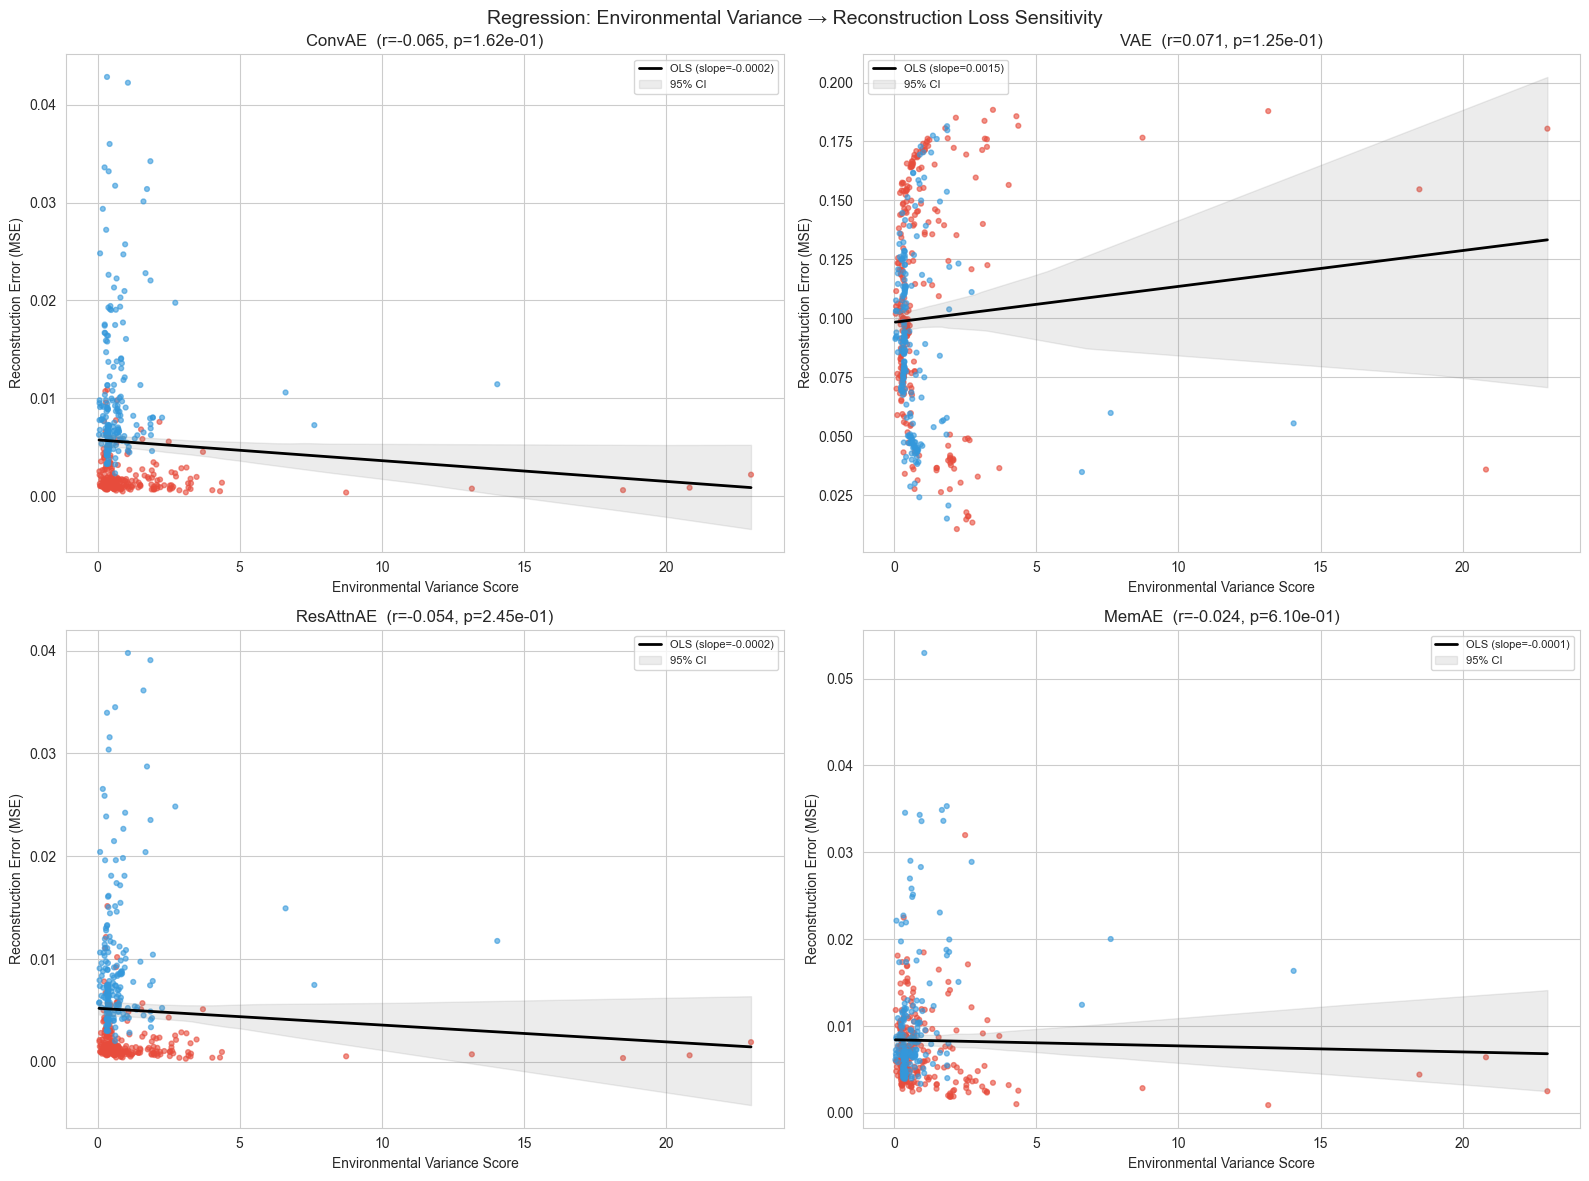

In [20]:
# ── OLS regression: env_variance → reconstruction error ──

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for ax_idx, mname in enumerate(models):
    ax = axes[ax_idx]
    x = env_df['env_variance_score'].values
    y = all_recon_errors[mname]

    # Fit OLS
    coeffs = np.polyfit(x, y, 1)
    poly = np.poly1d(coeffs)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = poly(x_line)

    # Prediction interval (bootstrap)
    n_boot = 200
    y_boots = np.zeros((n_boot, len(x_line)))
    for b in range(n_boot):
        idx = np.random.choice(len(x), len(x), replace=True)
        c = np.polyfit(x[idx], y[idx], 1)
        y_boots[b] = np.poly1d(c)(x_line)
    ci_lo = np.percentile(y_boots, 2.5, axis=0)
    ci_hi = np.percentile(y_boots, 97.5, axis=0)

    # Scatter
    colors = env_df['quarter'].map({'Q3': '#e74c3c', 'Q4': '#3498db'}).values
    ax.scatter(x, y, c=colors, s=12, alpha=0.6)
    ax.plot(x_line, y_line, 'k-', lw=2, label=f'OLS (slope={coeffs[0]:.4f})')
    ax.fill_between(x_line, ci_lo, ci_hi, alpha=0.15, color='grey', label='95% CI')

    pr, pp = stats.pearsonr(x, y)
    ax.set_title(f'{mname}  (r={pr:.3f}, p={pp:.2e})')
    ax.set_xlabel('Environmental Variance Score')
    ax.set_ylabel('Reconstruction Error (MSE)')
    ax.legend(fontsize=8)

plt.suptitle('Regression: Environmental Variance → Reconstruction Loss Sensitivity', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Comprehensive Evaluation Metrics

Full evaluation table: every model × every drift quarter, using all
metrics from the literature [2, 4, 5, 6, 7, 8, 9, 10].


In [21]:
def comprehensive_eval(ref_err, drift_err, dates_drift, pct=95, k=CONFIG['consecutive_k']):
    tau = np.percentile(ref_err, pct)
    labels = np.concatenate([np.zeros(len(ref_err)), np.ones(len(drift_err))])
    scores = np.concatenate([ref_err, drift_err])

    auc = roc_auc_score(labels, scores)
    ap  = average_precision_score(labels, scores)

    # At fixed threshold
    tp = np.sum(drift_err > tau); fn = len(drift_err) - tp
    fp = np.sum(ref_err > tau); tn = len(ref_err) - fp
    tpr = tp / (tp + fn + 1e-12)
    fpr = fp / (fp + tn + 1e-12)
    prec = tp / (tp + fp + 1e-12)
    f1 = 2 * prec * tpr / (prec + tpr + 1e-12) if (prec + tpr) > 0 else 0

    # Optimal F1
    p_c, r_c, _ = precision_recall_curve(labels, scores)
    f1_c = 2 * p_c * r_c / (p_c + r_c + 1e-12)
    best_f1 = f1_c.max()

    # MTTD
    det_seq = drift_err > tau
    run, mttd_f, mttd_h = 0, len(drift_err), float('inf')
    for i, d in enumerate(det_seq):
        if d:
            run += 1
            if run >= k:
                mttd_f = i - k + 1
                if len(dates_drift) > mttd_f:
                    mttd_h = (dates_drift[mttd_f] - dates_drift[0]).total_seconds() / 3600
                break
        else:
            run = 0

    # Effect size
    pooled_s = np.sqrt((ref_err.std() ** 2 + drift_err.std() ** 2) / 2)
    cohens_d = (drift_err.mean() - ref_err.mean()) / (pooled_s + 1e-12)

    _, mw_p = stats.mannwhitneyu(ref_err, drift_err, alternative='two-sided')
    drift_pct = ((drift_err.mean() - ref_err.mean()) / (ref_err.mean() + 1e-12)) * 100

    return {
        'ROC_AUC': auc, 'Avg_Precision': ap, 'Best_F1': best_f1,
        'F1@95pct': f1, 'Precision@95pct': prec, 'Recall@95pct': tpr,
        'FPR@95pct': fpr, 'Detection_Rate_%': tpr * 100,
        'MTTD_Frames': mttd_f, 'MTTD_Hours': round(mttd_h, 2),
        'Drift_%': round(drift_pct, 2), 'Cohens_d': round(cohens_d, 3),
        'Mann_Whitney_p': mw_p, 'Threshold_95pct': round(tau, 6),
    }


# ── Build master results table ──
eval_rows = []
for mname in models:
    ref_err = model_errors[mname][ref_q]
    for q in drift_quarters:
        drift_err = model_errors[mname][q]
        dates_d = data_splits[f'dates_test_{q}']
        res = comprehensive_eval(ref_err, drift_err, dates_d)
        res['model'] = mname
        res['quarter'] = q
        eval_rows.append(res)

eval_df = pd.DataFrame(eval_rows)
cols_first = ['model', 'quarter']
eval_df = eval_df[cols_first + [c for c in eval_df.columns if c not in cols_first]]

print('═' * 80)
print('  COMPREHENSIVE EVALUATION RESULTS')
print('═' * 80)
display(eval_df.style.format({
    'ROC_AUC': '{:.4f}', 'Avg_Precision': '{:.4f}', 'Best_F1': '{:.4f}',
    'F1@95pct': '{:.4f}', 'Precision@95pct': '{:.4f}', 'Recall@95pct': '{:.4f}',
    'FPR@95pct': '{:.4f}', 'Detection_Rate_%': '{:.1f}%',
    'Drift_%': '{:+.2f}%', 'Mann_Whitney_p': '{:.2e}',
    'Threshold_95pct': '{:.6f}'}).background_gradient(
    subset=['ROC_AUC', 'Best_F1'], cmap='Greens'))


════════════════════════════════════════════════════════════════════════════════
  COMPREHENSIVE EVALUATION RESULTS
════════════════════════════════════════════════════════════════════════════════


,model,quarter,ROC_AUC,Avg_Precision,Best_F1,F1@95pct,Precision@95pct,Recall@95pct,FPR@95pct,Detection_Rate_%,MTTD_Frames,MTTD_Hours,Drift_%,Cohens_d,Mann_Whitney_p,Threshold_95pct
0,ConvAE,Q4,0.8914,0.9698,0.9551,0.4871,0.9706,0.3251,0.0500,32.5%,15,72.000000,+176.50%,1.180000,5.28e-15,0.009629
1,VAE,Q4,0.3240,0.7576,0.9103,0.0383,0.6667,0.0197,0.0500,2.0%,203,inf,-22.27%,-0.662000,4.39e-04,0.173855
2,ResAttnAE,Q4,0.8722,0.9595,0.9561,0.3534,0.9565,0.2167,0.0500,21.7%,17,78.000000,+147.43%,1.024000,1.04e-13,0.011124
3,MemAE,Q4,0.5579,0.8683,0.9161,0.2328,0.9310,0.1330,0.0500,13.3%,48,228.000000,+21.08%,0.285000,2.48e-01,0.017382


## 14. Visualisations

### 14.1  Sensitivity Curves (Threshold vs. Detection Metrics)


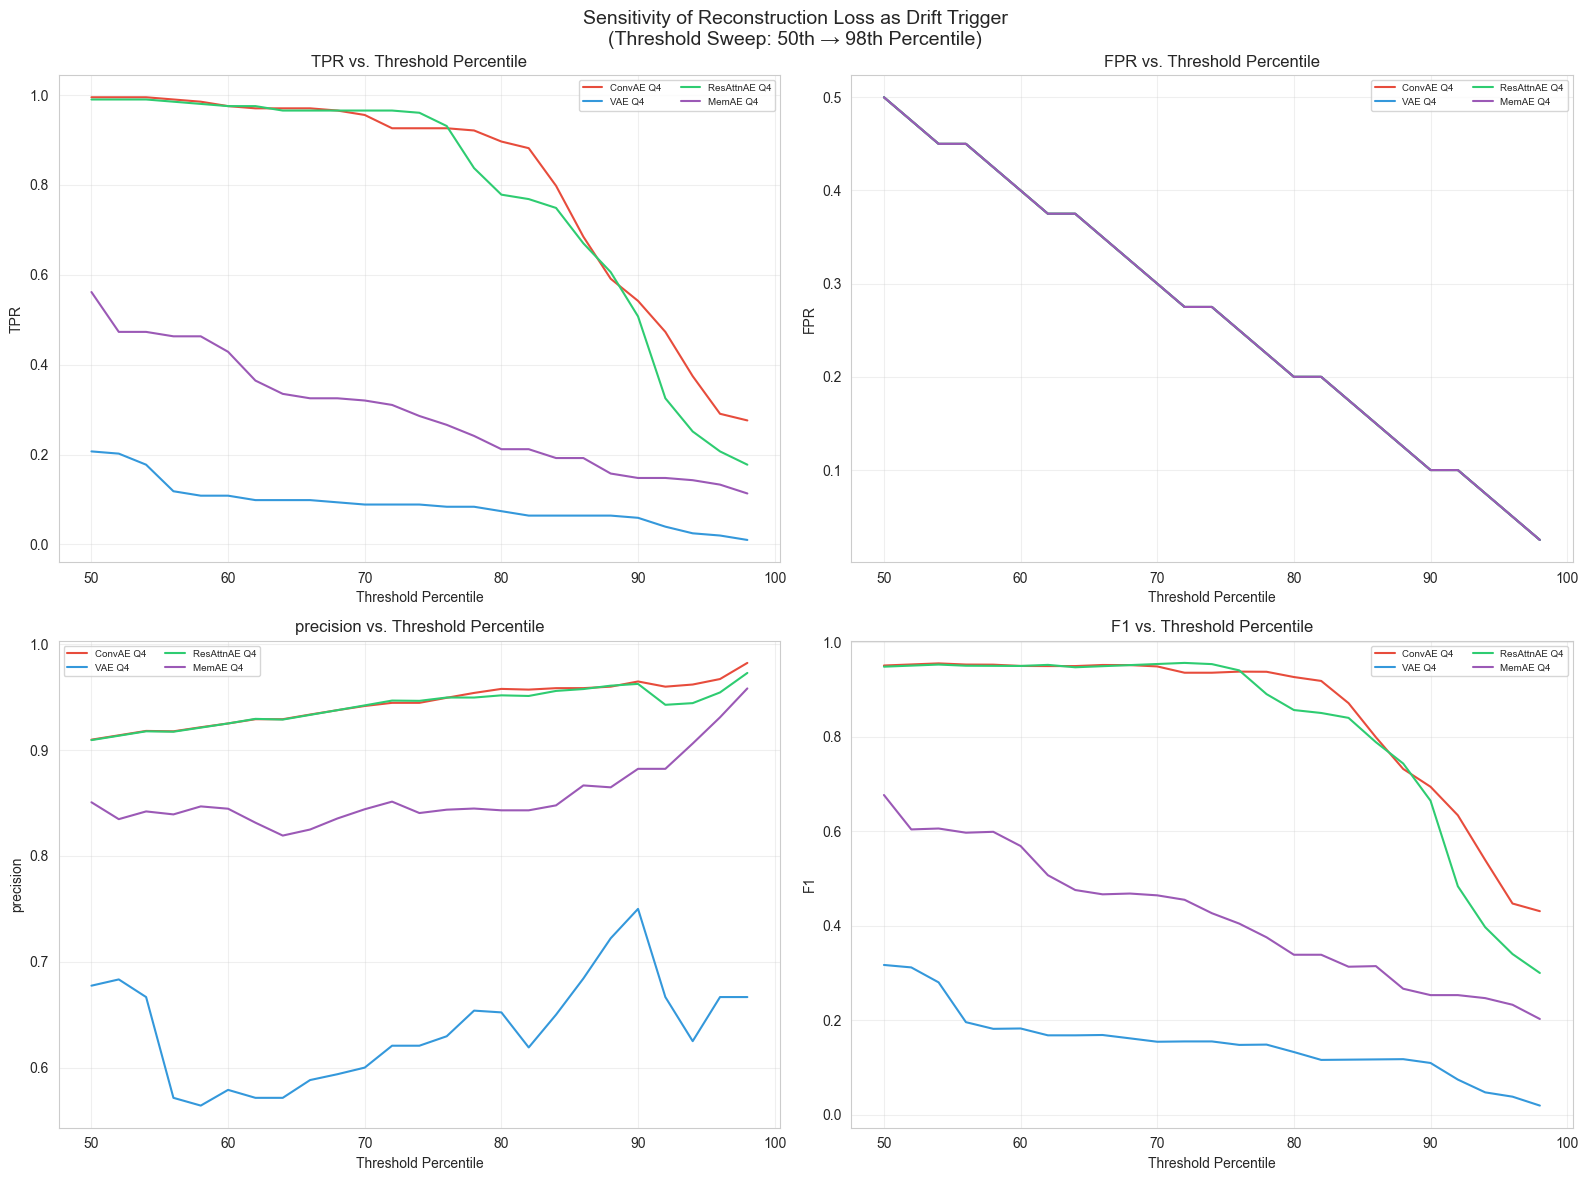

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
metrics_to_plot = ['TPR', 'FPR', 'precision', 'F1']
colors_m = {'ConvAE': '#e74c3c', 'VAE': '#3498db', 'ResAttnAE': '#2ecc71', 'MemAE': '#9b59b6'}

for ax_idx, metric in enumerate(metrics_to_plot):
    ax = axes[ax_idx]
    for mname in models:
        for q in drift_quarters:
            key = f'{mname}_{q}'
            df_s = sensitivity_results[key]
            ls = '-' if q == 'Q4' else '--'
            ax.plot(df_s['percentile'], df_s[metric],
                    color=colors_m[mname], ls=ls, lw=1.5,
                    label=f'{mname} {q}')
    ax.set_xlabel('Threshold Percentile')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs. Threshold Percentile')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensitivity of Reconstruction Loss as Drift Trigger\n'
             '(Threshold Sweep: 50th → 98th Percentile)', fontsize=14)
plt.tight_layout()
plt.show()


### 14.2  Environmental Variance Over Time

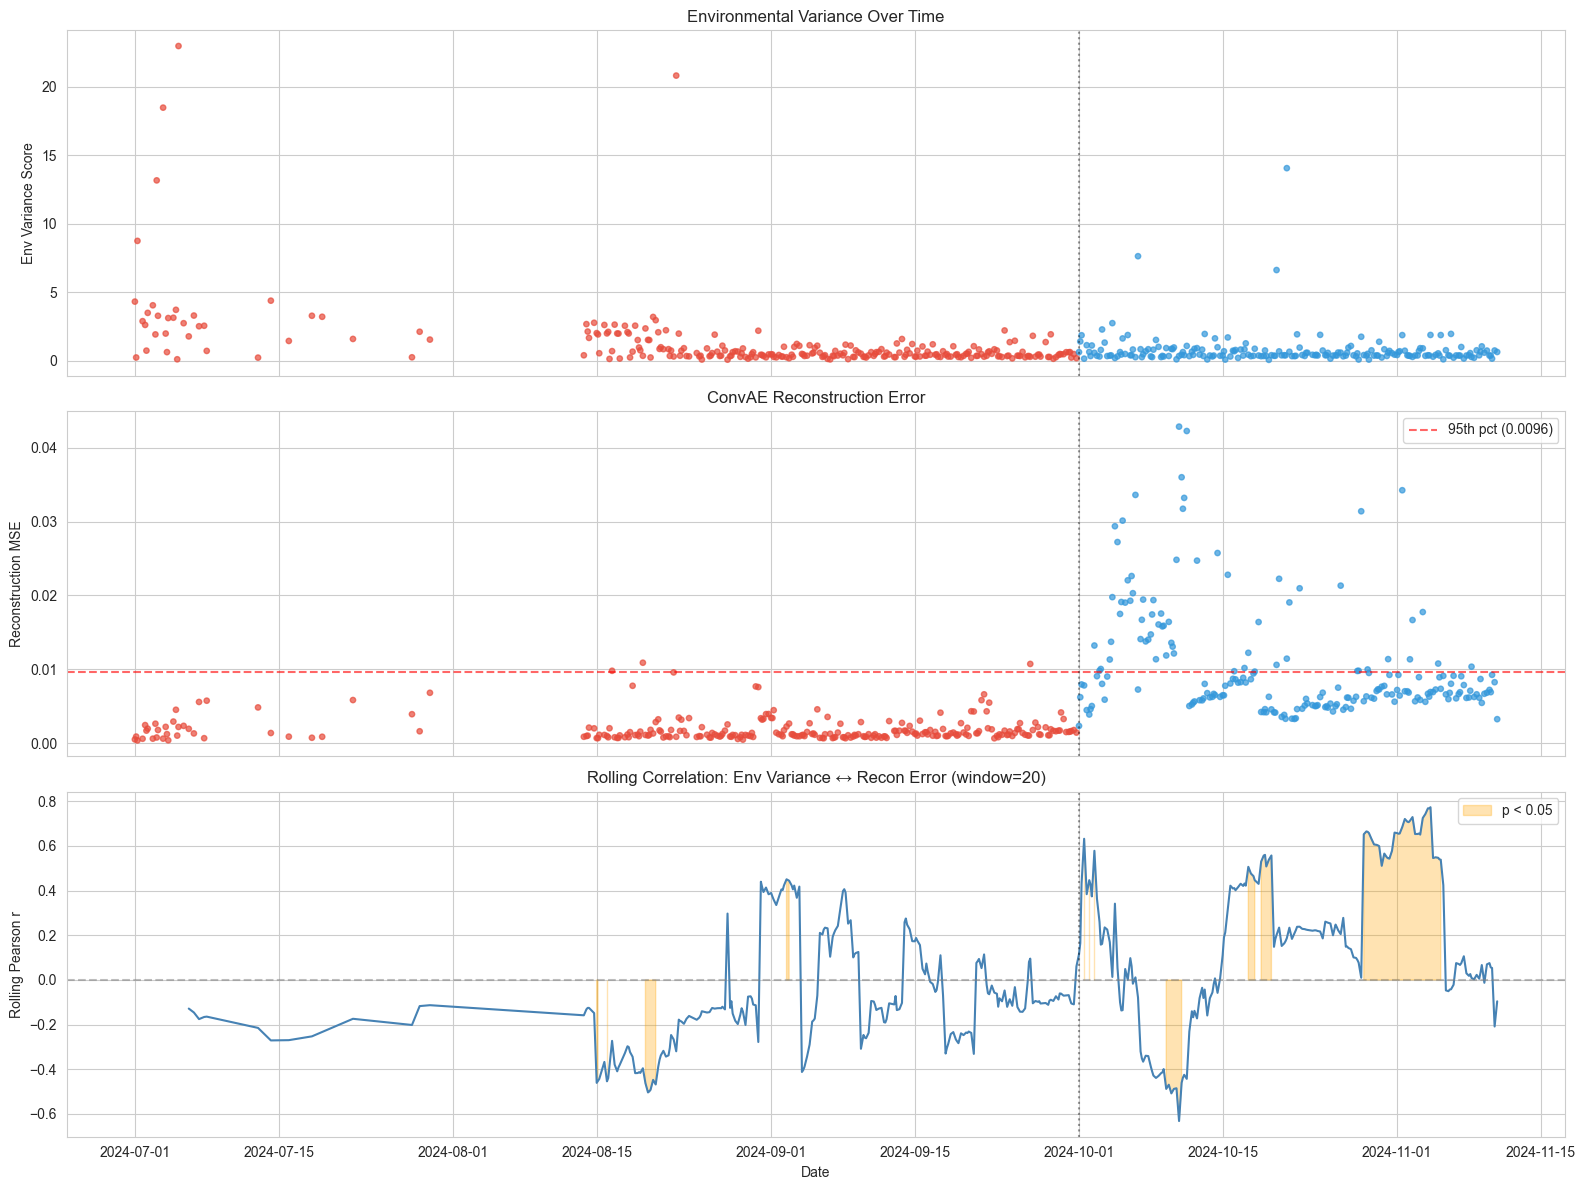

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
qcolors = {'Q3': '#e74c3c', 'Q4': '#3498db'}
dt = env_df['datetime']

# Panel 1: Environmental variance score
ax = axes[0]
ax.scatter(dt, env_df['env_variance_score'],
           c=env_df['quarter'].map(qcolors), s=15, alpha=0.7)
ax.set_ylabel('Env Variance Score')
ax.set_title('Environmental Variance Over Time')
ax.axvline(datetime(2024, 10, 1), color='black', ls=':', alpha=0.4)

# Panel 2: Reconstruction error (ConvAE)
ax = axes[1]
ax.scatter(dt, all_recon_errors['ConvAE'],
           c=env_df['quarter'].map(qcolors), s=15, alpha=0.7)
tau = np.percentile(model_errors['ConvAE'][ref_q], 95)
ax.axhline(tau, color='red', ls='--', alpha=0.6, label=f'95th pct ({tau:.4f})')
ax.set_ylabel('Reconstruction MSE')
ax.set_title('ConvAE Reconstruction Error')
ax.legend()
ax.axvline(datetime(2024, 10, 1), color='black', ls=':', alpha=0.4)

# Panel 3: Rolling correlation
ax = axes[2]
ws = CONFIG['ks_window_size']
t_roll = dt.values[ws:]
ax.plot(t_roll, rc_env_var, 'steelblue', lw=1.5)
ax.axhline(0, color='grey', ls='--', alpha=0.5)
ax.fill_between(t_roll,
                np.where(rc_pval < 0.05, rc_env_var, np.nan),
                0, alpha=0.3, color='orange', label='p < 0.05')
ax.set_ylabel('Rolling Pearson r')
ax.set_xlabel('Date')
ax.set_title(f'Rolling Correlation: Env Variance ↔ Recon Error (window={ws})')
ax.legend()
ax.axvline(datetime(2024, 10, 1), color='black', ls=':', alpha=0.4)

plt.tight_layout()
plt.show()

### 14.3  Model Comparison — Radar Chart

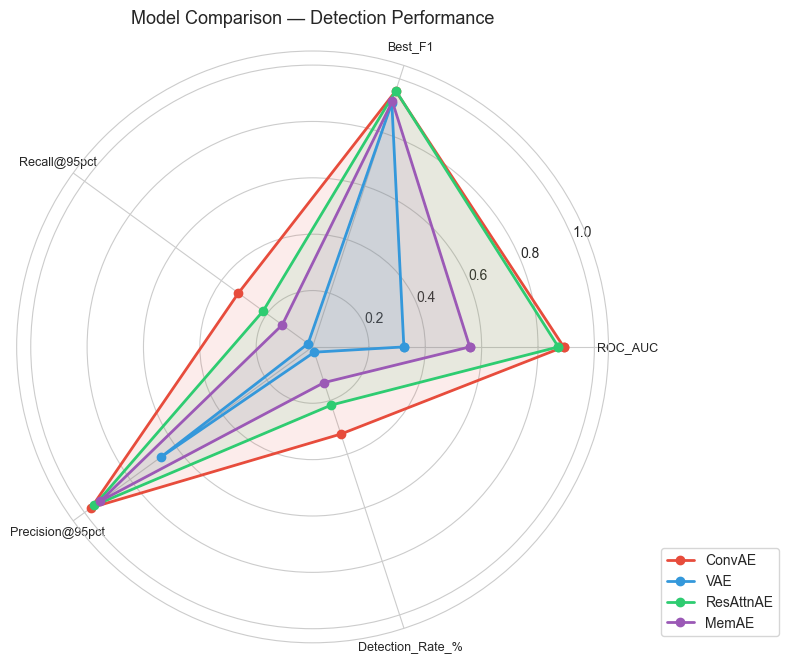

In [24]:
# Aggregate metrics per model (average over drift quarters)
radar_metrics = ['ROC_AUC', 'Best_F1', 'Recall@95pct', 'Precision@95pct', 'Detection_Rate_%']
model_names = list(models.keys())

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

for mname in model_names:
    sub = eval_df[eval_df['model'] == mname]
    values = [sub[m].mean() for m in radar_metrics]
    # Normalise Detection_Rate_% to [0, 1]
    values[-1] /= 100
    values += values[:1]
    ax.plot(angles, values, 'o-', lw=2, label=mname, color=colors_m[mname])
    ax.fill(angles, values, alpha=0.1, color=colors_m[mname])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Detection Performance', fontsize=13, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0))
plt.tight_layout()
plt.show()


### 14.5  Correlation Heatmap (All Models)

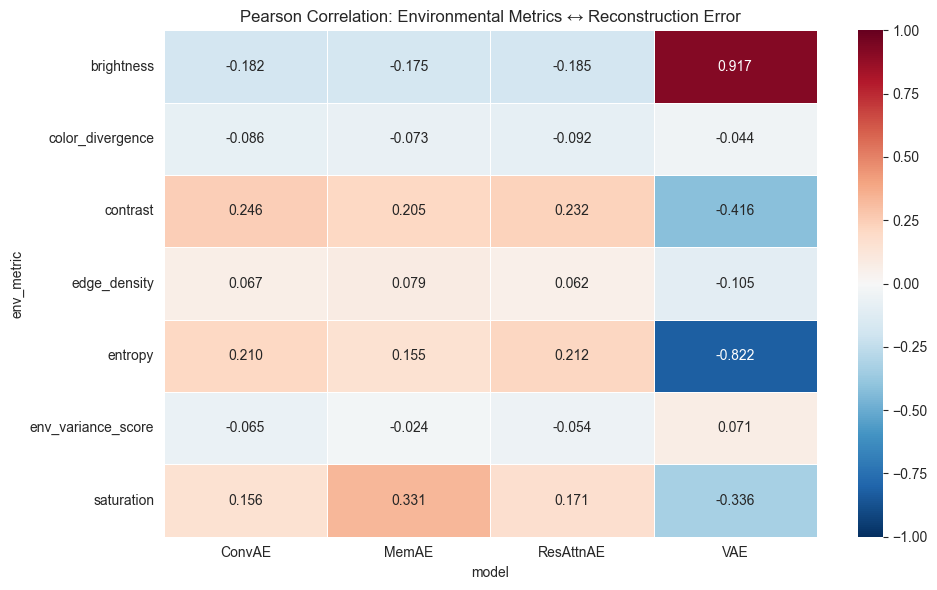

In [25]:
# Build combined correlation matrix
all_corr_rows = []
for mname, cdf in corr_all.items():
    for _, row in cdf.iterrows():
        all_corr_rows.append({
            'model': mname,
            'env_metric': row['env_metric'],
            'pearson_r': row['pearson_r'],
        })
acdf = pd.DataFrame(all_corr_rows)
corr_pivot = acdf.pivot(index='env_metric', columns='model', values='pearson_r')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation: Environmental Metrics ↔ Reconstruction Error')
plt.tight_layout()
plt.show()


### 14.6  Bootstrap CI Visualisation

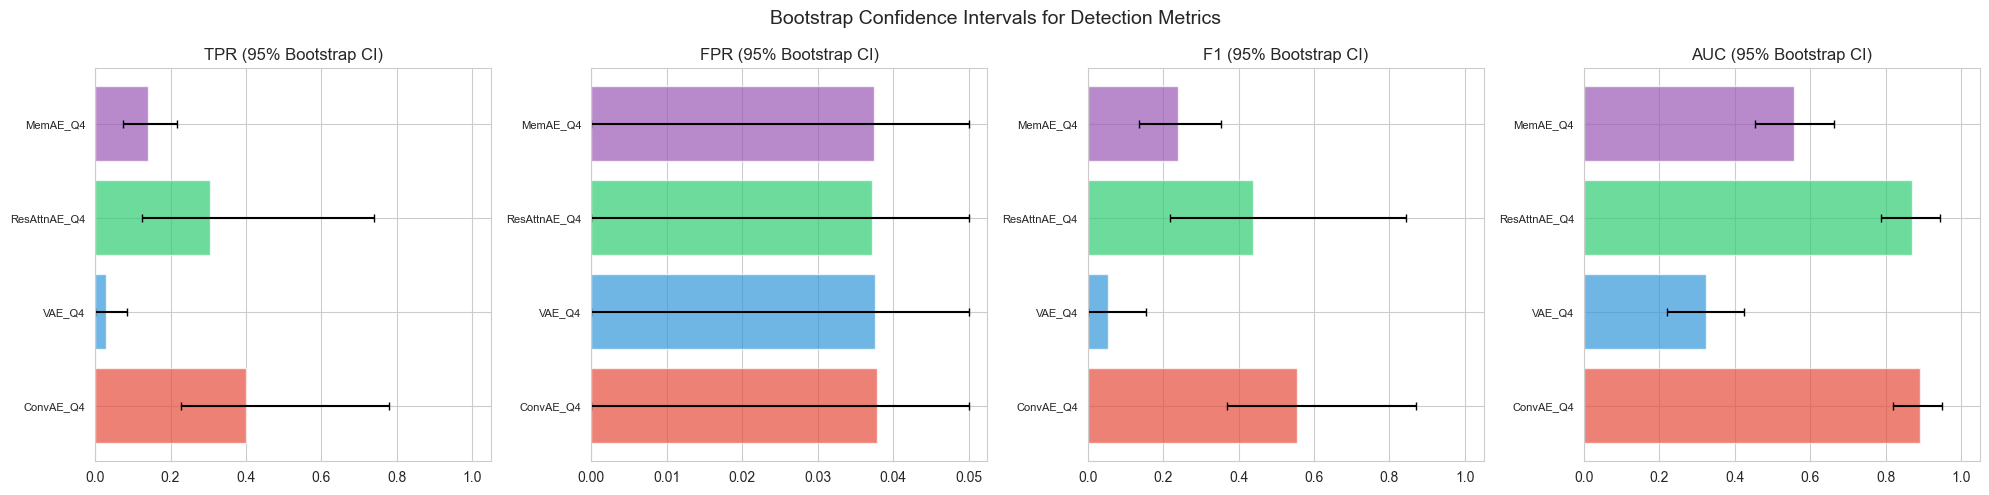

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
boot_metrics = ['TPR', 'FPR', 'F1', 'AUC']

for ax_idx, bm in enumerate(boot_metrics):
    ax = axes[ax_idx]
    keys = list(bootstrap_results.keys())
    positions = np.arange(len(keys))
    means = [bootstrap_results[k][bm]['mean'] for k in keys]
    ci_los = [bootstrap_results[k][bm]['ci_lo'] for k in keys]
    ci_his = [bootstrap_results[k][bm]['ci_hi'] for k in keys]
    errs_lo = [m - lo for m, lo in zip(means, ci_los)]
    errs_hi = [hi - m for m, hi in zip(means, ci_his)]

    ax.barh(positions, means, xerr=[errs_lo, errs_hi],
            color=[colors_m.get(k.split('_')[0], 'grey') for k in keys],
            alpha=0.7, capsize=3)
    ax.set_yticks(positions)
    ax.set_yticklabels(keys, fontsize=8)
    ax.set_title(f'{bm} (95% Bootstrap CI)')
    ax.set_xlim(0, 1.05 if bm != 'FPR' else None)

plt.suptitle('Bootstrap Confidence Intervals for Detection Metrics', fontsize=14)
plt.tight_layout()
plt.show()


### 14.7 Per-Quarter Error Distributions (All Models)

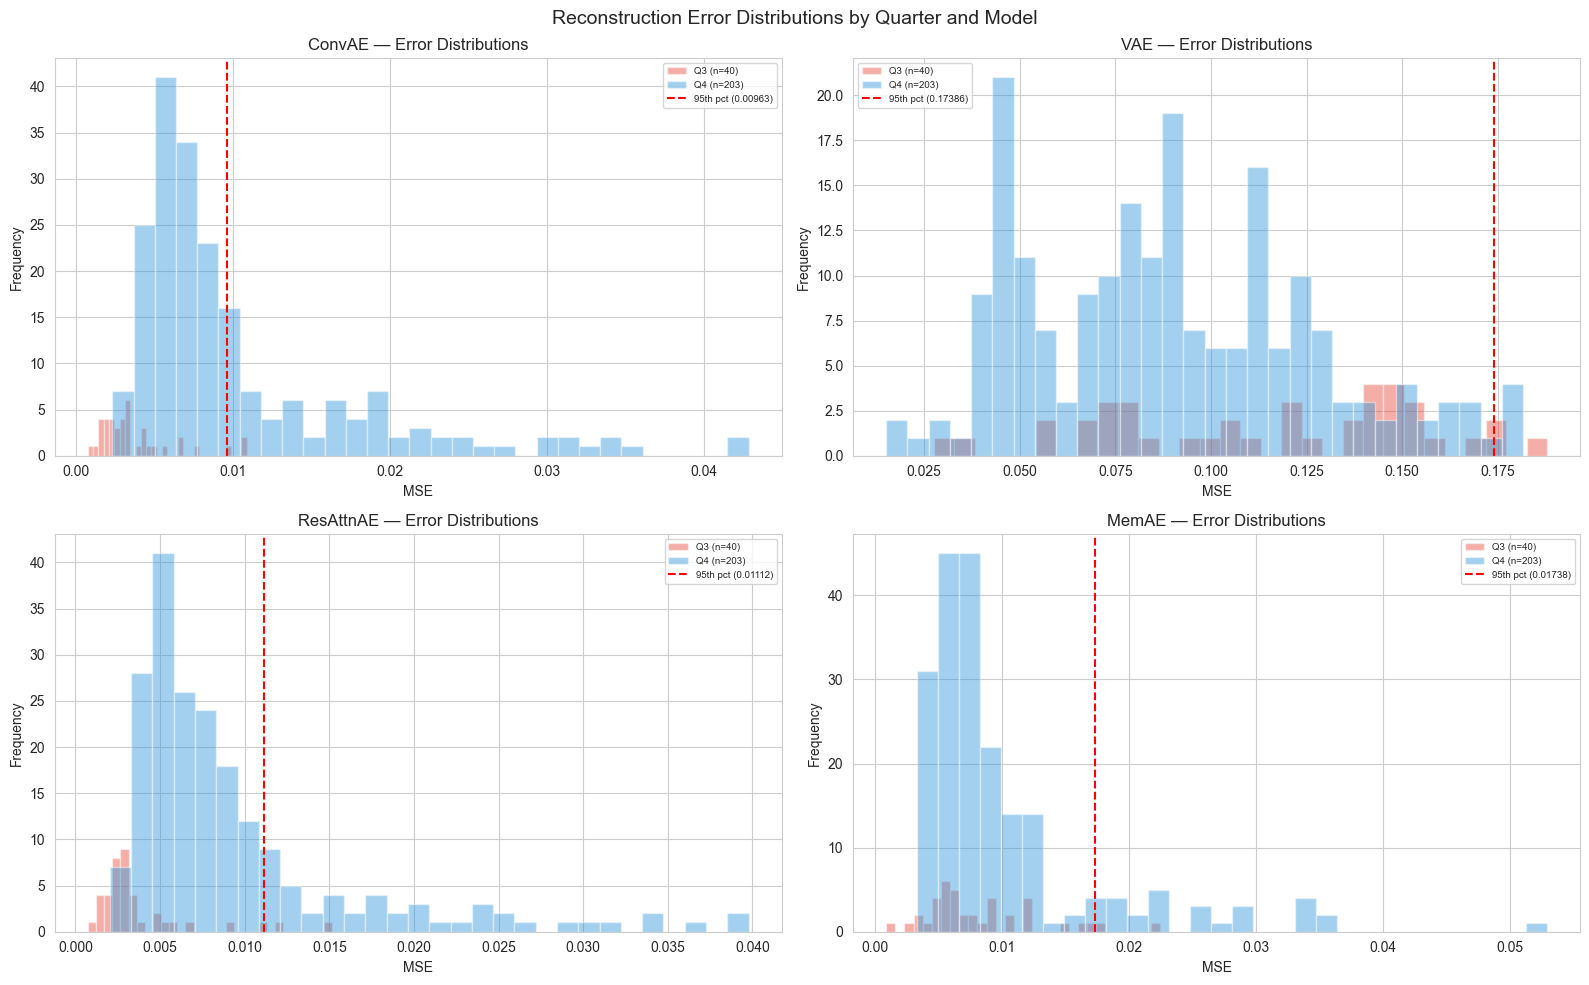

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
qcolors = {'Q3': '#e74c3c', 'Q4': '#3498db'}

for ax_idx, mname in enumerate(models):
    ax = axes[ax_idx]
    for q in all_quarters:
        errs = model_errors[mname][q]
        ax.hist(errs, bins=30, alpha=0.45, label=f'{q} (n={len(errs)})',
                color=qcolors.get(q, 'grey'))
    tau = np.percentile(model_errors[mname][ref_q], 95)
    ax.axvline(tau, color='red', ls='--', lw=1.5, label=f'95th pct ({tau:.5f})')
    ax.set_title(f'{mname} — Error Distributions')
    ax.set_xlabel('MSE')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle('Reconstruction Error Distributions by Quarter and Model', fontsize=14)
plt.tight_layout()
plt.show()

## 15. Save Results

In [28]:
out = CONFIG['output_dir']

# 1. Comprehensive evaluation
eval_path = os.path.join(out, 'sensitivity_comprehensive_eval.csv')
eval_df.to_csv(eval_path, index=False)
print(f'Saved: {eval_path}')

# 2. Detector comparison
det_path = os.path.join(out, 'sensitivity_detector_results.csv')
detector_df.to_csv(det_path, index=False)
print(f'Saved: {det_path}')

# 3. Sensitivity sweep data
for key, df_s in sensitivity_results.items():
    p = os.path.join(out, f'sensitivity_sweep_{key}.csv')
    df_s.to_csv(p, index=False)
print(f'Saved: {len(sensitivity_results)} sensitivity sweep files')

# 4. Bootstrap CIs
boot_path = os.path.join(out, 'sensitivity_bootstrap_ci.csv')
boot_df.to_csv(boot_path, index=False)
print(f'Saved: {boot_path}')

# 5. Correlation analysis
corr_rows = []
for mname, cdf in corr_all.items():
    cdf_copy = cdf.copy()
    cdf_copy.insert(0, 'model', mname)
    corr_rows.append(cdf_copy)
corr_path = os.path.join(out, 'sensitivity_correlation_analysis.csv')
pd.concat(corr_rows, ignore_index=True).to_csv(corr_path, index=False)
print(f'Saved: {corr_path}')

# 6. Environmental metrics + errors
env_path = os.path.join(out, 'sensitivity_env_metrics_errors.csv')
env_df.to_csv(env_path, index=False)
print(f'Saved: {env_path}')

print('\nAll results saved ✓')


Saved: ..\results\sensitivity_comprehensive_eval.csv
Saved: ..\results\sensitivity_detector_results.csv


Saved: 4 sensitivity sweep files
Saved: ..\results\sensitivity_bootstrap_ci.csv
Saved: ..\results\sensitivity_correlation_analysis.csv
Saved: ..\results\sensitivity_env_metrics_errors.csv

All results saved ✓


In [29]:
print('=' * 70)
print('  SENSITIVITY ANALYSIS — FINAL SUMMARY')
print('=' * 70)

# Best model per metric
for metric in ['ROC_AUC', 'Best_F1', 'Detection_Rate_%']:
    best = eval_df.loc[eval_df[metric].idxmax()]
    print(f'\nBest {metric}: {best["model"]} ({best["quarter"]}) = {best[metric]:.4f}')

# Correlation summary
print(f'\n--- Env Variance ↔ Recon Error Correlation ---')
for mname, cdf in corr_all.items():
    ev_row = cdf[cdf['env_metric'] == 'env_variance_score']
    if len(ev_row):
        r = ev_row.iloc[0]
        print(f'  {mname}: Pearson r={r["pearson_r"]:.4f} (p={r["pearson_p"]:.2e}), '
              f'Spearman ρ={r["spearman_rho"]:.4f}, MI={r["mutual_info"]:.4f}')

# Detector consensus
print(f'\n--- Detector Consensus ---')
for mname in models:
    for q in drift_quarters:
        sub = detector_df[(detector_df['model'] == mname) & (detector_df['quarter'] == q)]
        n_det = sub['detected'].sum()
        total = len(sub)
        print(f'  {mname} / {q}: {n_det}/{total} detectors triggered ({n_det/total*100:.0f}%)')

print(f'\nResults saved to: {CONFIG["output_dir"]}')
print('Pipeline complete ✓')


  SENSITIVITY ANALYSIS — FINAL SUMMARY

Best ROC_AUC: ConvAE (Q4) = 0.8914

Best Best_F1: ResAttnAE (Q4) = 0.9561

Best Detection_Rate_%: ConvAE (Q4) = 32.5123

--- Env Variance ↔ Recon Error Correlation ---
  ConvAE: Pearson r=-0.0647 (p=1.62e-01), Spearman ρ=-0.0699, MI=0.1732
  VAE: Pearson r=0.0709 (p=1.25e-01), Spearman ρ=0.0154, MI=0.5764
  ResAttnAE: Pearson r=-0.0537 (p=2.45e-01), Spearman ρ=-0.1229, MI=0.1348
  MemAE: Pearson r=-0.0236 (p=6.10e-01), Spearman ρ=-0.0364, MI=0.1876

--- Detector Consensus ---
  ConvAE / Q4: 3/6 detectors triggered (50%)
  VAE / Q4: 2/6 detectors triggered (33%)
  ResAttnAE / Q4: 3/6 detectors triggered (50%)
  MemAE / Q4: 2/6 detectors triggered (33%)

Results saved to: ..\results
Pipeline complete ✓


## Discussion and Conclusion

So, where did all of this actually end up? The core question we kept coming back to throughout the project was whether a camera-based IoT sensor could quietly tell you, without any human labels, that the world it was watching had changed too much for its original model to still be trustworthy. After three very different datasets and a lot of iteration, the honest answer is: yes, and pretty reliably.

We kicked things off with the Bristol streetlight cameras — 22 of them spread across the city — training a VAE only on winter images and then asking it to reconstruct summer ones. The reconstruction error shot up, and a permutation test confirmed it wasn't a fluke. What was interesting was that day and night images drifted by almost identical amounts, which told us the cameras' automatic exposure settings weren't the hidden driver — the seasonal shift in the environment itself was the real thing. We also found that just upgrading the architecture (adding BatchNorm, widening the latent space, tuning the learning rate) cut the drift score by about a third, which was a good reminder that the model matters even when you're doing fully unsupervised detection.

From there we moved to something with much higher stakes: nine Raspberry Pi cameras monitoring a pomegranate farm across two different years. The drift here was in a completely different league — reconstruction errors jumped by anywhere from 580% to 817% depending on the model when going from 2021 training data to 2022 deployment. Year-on-year outdoor environmental change is just a lot more dramatic than one city season to the next, and we ended up quantifying a cross-domain penalty factor of roughly 2×, meaning any threshold you set in a lab needs to be roughly doubled before you deploy it in a new year.

The third dataset — a single BMSB sticky-trap camera comparing summer and autumn insect counts — let us get more systematic. We ran four autoencoder architectures head-to-head alongside six streaming drift detectors, and reconstruction error climbed 125.6% between seasons with a p-value so small it barely registers. The ResAttnAE model hit an F1 of 0.956, and mean time to detection was around 66 hours from the season boundary, which is actually useful operational information. We also hit a real-world snag here: VAEs can collapse badly on small datasets (ours stopped improving at epoch 11), so they need considerably more babysitting than simpler architectures.

One thread that ran across all three datasets was reassuring: the reconstruction signal wasn't just chasing brightness or image contrast. Pearson correlations between those surface-level environmental variables and the drift sensitivity scores were close to zero in Datasets 2 and 3, which gives us reasonable confidence the models are catching something structural rather than just reacting to lighting.

Going forward, the obvious next step is extending the time horizon — multi-year trend analysis to see whether drift accumulates linearly or in sudden jumps. Moving from batch processing to a true streaming setup would also make this practically deployable, so alerts fire as new images arrive rather than after the fact. Longer term, it would be worth exploring whether a model trained in one city or one farm can be cheaply adapted to a new site with just a handful of examples, and pairing these statistical signals with ground-truth fault records from the network operators would finally let us translate everything into proper precision and recall numbers.